# Assignment 3 — Forward Propagation, Backpropagation & Hyperparameter Analysis

### Objective
Implement a neural network using TensorFlow/Keras and analyze how different **learning rates** and **numbers of epochs** affect model performance.

**Dataset:** MNIST handwritten digits  
**Framework:** TensorFlow / Keras  
**Optimizer:** Adam  
**Environment:** Google Colab / Python 3

## 1. Import Required Libraries

TensorFlow/Keras handles the neural-network implementation and optimization. NumPy is used for numerical operations and Matplotlib is used for visualization.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.optimizers import Adam

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Load the MNIST Dataset

MNIST contains 28×28 grayscale images of handwritten digits from 0 to 9. Keras provides separate training and testing datasets.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


## 3. Visualize Sample Images

A sample of ten training images is displayed to verify the input data and corresponding digit labels.

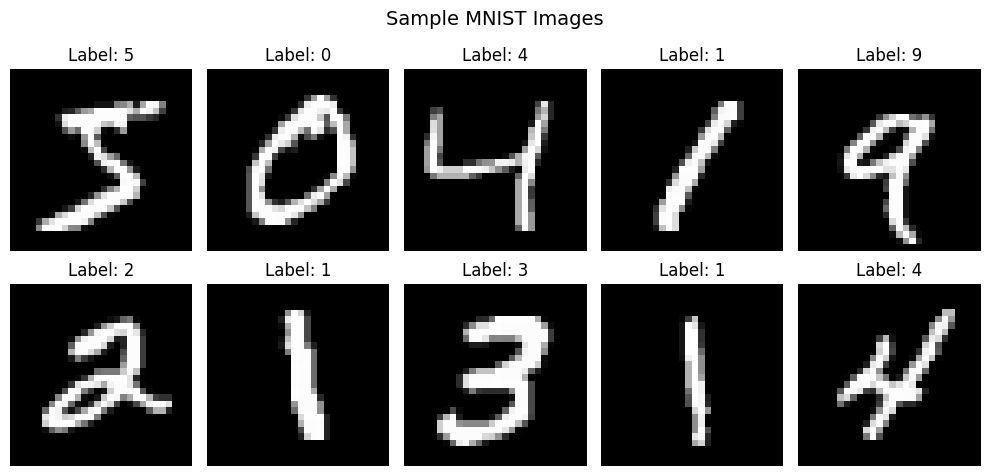

In [3]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.suptitle("Sample MNIST Images", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Normalize the Input Data

MNIST pixel values range from 0 to 255. Dividing by 255 scales them to the range 0–1, making optimization more stable.

In [4]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training pixel range:", x_train.min(), "to", x_train.max())
print("Testing pixel range:", x_test.min(), "to", x_test.max())

Training pixel range: 0.0 to 1.0
Testing pixel range: 0.0 to 1.0


## 5. Forward Propagation and Backpropagation

In a neural network, **forward propagation** passes the input through the layers to produce predictions. The loss function measures the prediction error. During **backpropagation**, gradients of the loss are propagated backward and the optimizer updates the model weights to reduce the error.

Keras performs these operations automatically when `model.fit()` is called. The `Adam` optimizer applies the calculated gradients using the selected learning rate.

## 6. Define the Neural Network

The model contains two hidden dense layers using ReLU activation and a 10-neuron softmax output layer for digit classification. `Input()` is used explicitly to define the input shape.

In [5]:
def create_model(learning_rate):
    model = Sequential([
        Input(shape=(28, 28)),
        Flatten(),
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(10, activation="softmax")
    ])

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## 7. Hyperparameter Experiment

Three learning rates and three epoch counts are tested:

- Learning rates: **0.1, 0.01, 0.001**
- Epochs: **5, 10, 20**

This creates **9 experimental configurations**. Each configuration starts with a newly initialized model so that the comparison focuses on the selected hyperparameters.

In [6]:
learning_rates = [0.1, 0.01, 0.001]
epochs_list = [5, 10, 20]

results = []
histories = {}

for learning_rate in learning_rates:
    for epochs in epochs_list:
        print("=" * 60)
        print(f"Learning Rate: {learning_rate} | Epochs: {epochs}")

        # Reinitialize the model for every configuration.
        tf.keras.backend.clear_session()
        model = create_model(learning_rate)

        history = model.fit(
            x_train,
            y_train,
            epochs=epochs,
            validation_data=(x_test, y_test),
            verbose=1
        )

        loss, accuracy = model.evaluate(x_test, y_test, verbose=0)

        results.append({
            "Learning Rate": learning_rate,
            "Epochs": epochs,
            "Accuracy": accuracy,
            "Loss": loss
        })

        histories[(learning_rate, epochs)] = history.history

Learning Rate: 0.1 | Epochs: 5
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.1316 - loss: 2.3435 - val_accuracy: 0.0974 - val_loss: 2.3112
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.1030 - loss: 2.3132 - val_accuracy: 0.1135 - val_loss: 2.3107
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.1003 - loss: 2.3143 - val_accuracy: 0.1135 - val_loss: 2.3069
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.1030 - loss: 2.3138 - val_accuracy: 0.0980 - val_loss: 2.3191
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.1024 - loss: 2.3141 - val_accuracy: 0.0958 - val_loss: 2.3155
Learning Rate: 0.1 | Epochs: 10
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.3699 - loss: 1.7263 - val_accuracy: 0.3512 - val_loss: 1.5425
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.3378 - loss: 1.5745 - val_accuracy: 0.2912 - val_loss: 1.6254
Epoch 3/10
1875/1875 ━━━━━━━━

## 8. Compare Experimental Results

The final test accuracy and loss for all nine configurations are collected into a table for direct comparison.

In [7]:
results_df = pd.DataFrame(results)
results_df["Accuracy"] = results_df["Accuracy"].round(4)
results_df["Loss"] = results_df["Loss"].round(4)

display(results_df)

,Learning Rate,Epochs,Accuracy,Loss
0,0.100,5,0.0958,2.3155
1,0.100,10,0.2005,1.8936
2,0.100,20,0.2069,1.8754
3,0.010,5,0.9545,0.1849
4,0.010,10,0.9705,0.1532
5,0.010,20,0.9678,0.2032
6,0.001,5,0.9759,0.0851
7,0.001,10,0.9790,0.0917
8,0.001,20,0.9795,0.1145


## 9. Visualize the Effect of Learning Rate and Epochs

The bar chart compares test accuracy across all combinations of learning rate and epoch count.

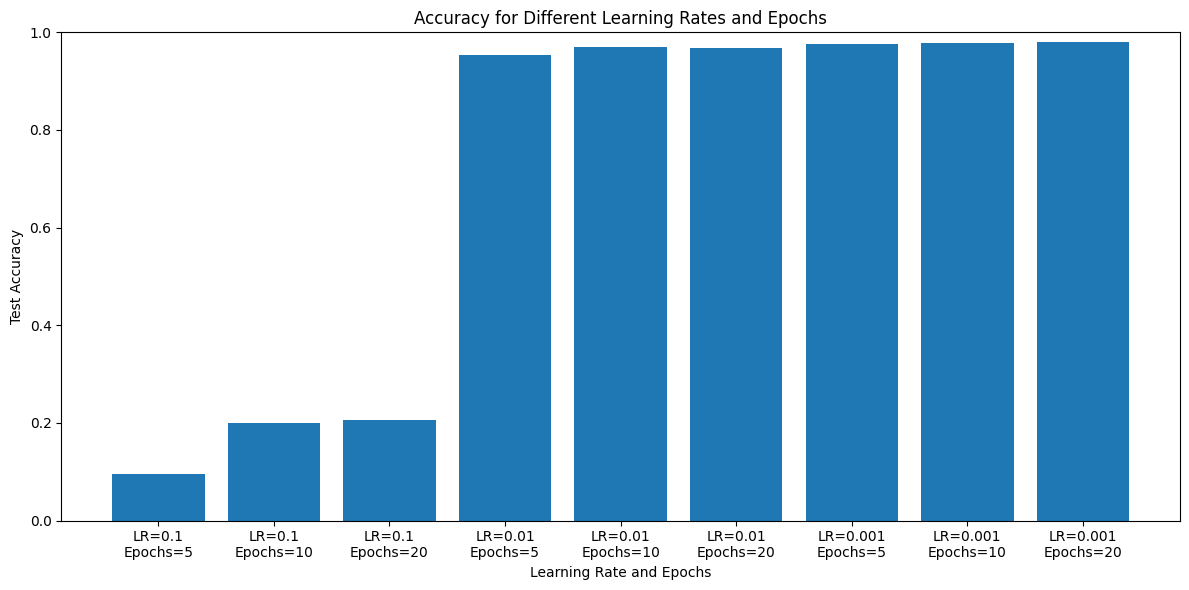

In [8]:
labels = [f"LR={lr}\nEpochs={ep}" for lr, ep in zip(results_df["Learning Rate"], results_df["Epochs"])]

plt.figure(figsize=(12, 6))
plt.bar(labels, results_df["Accuracy"])
plt.title("Accuracy for Different Learning Rates and Epochs")
plt.xlabel("Learning Rate and Epochs")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 10. Training Curves for the Best Configuration

The original experiment shows that the **0.001 learning rate with 10 epochs** achieved the highest recorded test accuracy. The corresponding training history is visualized below.

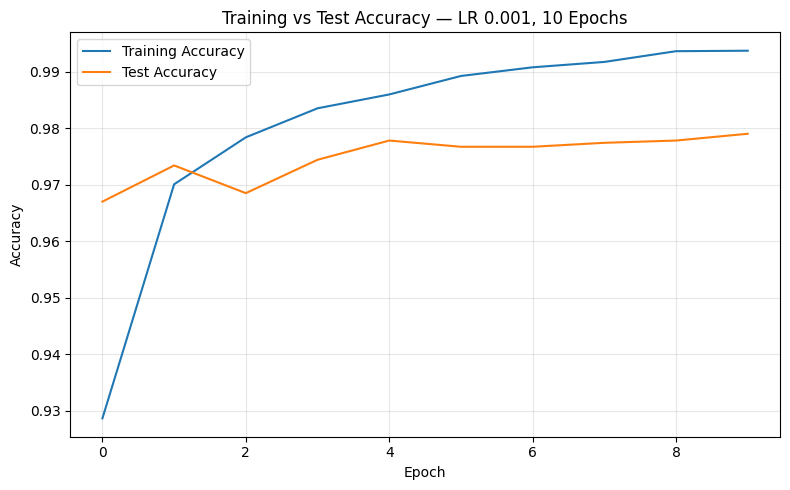

In [9]:
best_history = histories[(0.001, 10)]

plt.figure(figsize=(8, 5))
plt.plot(best_history["accuracy"], label="Training Accuracy")
plt.plot(best_history["val_accuracy"], label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Test Accuracy — LR 0.001, 10 Epochs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

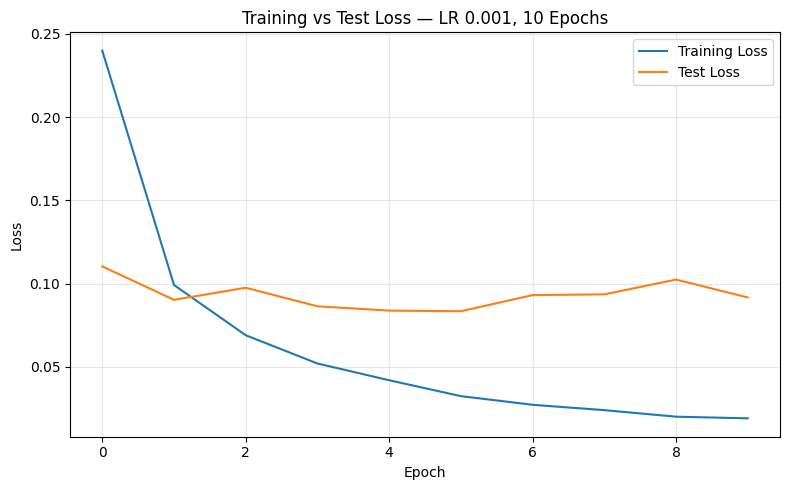

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(best_history["loss"], label="Training Loss")
plt.plot(best_history["val_loss"], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Test Loss — LR 0.001, 10 Epochs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Analysis

Based on the submitted experiment:

- A learning rate of **0.1** performed poorly and remained around 18–20% accuracy, indicating that the updates were too aggressive for this setup.
- A learning rate of **0.01** produced much better performance, around 96.5% accuracy.
- A learning rate of **0.001** produced the strongest results, with the best recorded accuracy at 10 epochs.
- Increasing the number of epochs does not always improve test performance. For example, with a learning rate of 0.001, accuracy increased from 97.18% at 5 epochs to 97.93% at 10 epochs, then decreased slightly to 97.65% at 20 epochs.

Therefore, the learning rate has a major effect on convergence, while the number of epochs should be selected based on observed performance rather than simply maximizing training duration.

## Conclusion

Forward propagation and backpropagation were implemented through TensorFlow/Keras model training. The experiment demonstrated that learning-rate selection strongly affects optimization and classification performance. Among the tested configurations in the submitted run, **learning rate = 0.001 and epochs = 10** gave the highest test accuracy of **97.93%**.